# Figure3_2

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure3")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest

from functions.load_data import loadTrialsM
from functions.utils import first_trials_by_image
from functions.plotting import set_paper_theme

set_paper_theme(tick_width=0.3)


### Categorical baseline

In [3]:
task_list  = ["animate_vs_inanimate","human_vs_monkey","monkey_vs_mammal","mammal_vs_reptile","natural_vs_artificial","electronics_vs_tools"]

In [4]:

lr_categorical = []
for monkey in ["Elsa","Judy","Olaf"]:
    lr_monkey = []
    for i,task in enumerate(task_list):
        trials,_ = loadTrialsM(task,monkey,islearn=False,extend=False)
        lr_monkey_task = [np.mean([tr["result"]=="CORRECT" for tr in trials[n]]) for n in range(4)]
        lr_monkey.append(lr_monkey_task)
    lr_categorical.append(np.mean(lr_monkey,axis=0))


In [5]:

task_list  = ["animate_vs_inanimate_gen","human_vs_monkey_gen","monkey_vs_mammal_gen","mammal_vs_reptile_gen","natural_vs_artificial_gen","electronics_vs_tools_gen"]
cr_categorical,se_categorical = [],[]
for monkey in ["Elsa","Judy","Olaf"]:
    cr_monkey = []
    for i,task in enumerate(task_list):
        trials,_ = loadTrialsM(task,monkey,islearn=False,extend=True)
        trials_gen = [trial for trial in trials if trial["trial_type"]=="gen"]
        first_trials,_ = first_trials_by_image(trials_gen)
        cr_monkey.append(np.mean([tr["result"]=="CORRECT" for tr in first_trials]))
    cr_categorical.append(np.mean(cr_monkey))
    se_categorical.append(np.std(cr_monkey)/np.sqrt(len(cr_monkey)))


### Randomization_L2

In [6]:
lr_L2 = []
res_L2 = []
for monkey in ["Elsa","Judy","Olaf"]:
    trials,_ = loadTrialsM("randomization_test_L2",monkey,islearn=False,extend=False)
    lr_monkey = [np.mean([tr["result"]=="CORRECT" for tr in trials[n]]) for n in range(6)]
    res_monkey = [[tr["result"]=="CORRECT" for tr in trials[n]] for n in range(6)]
    lr_L2.append(lr_monkey)
    res_L2.append(res_monkey)

In [7]:

print("Randomization L2; Binomial Test")
for i,monkey in enumerate(["Elsa","Judy","Olaf"]):
    for j in range(4):
        res = res_L2[i][j]
        result = binomtest(int(np.sum(res)), n=len(res), p=lr_categorical[i][j], alternative='less')

        print(f"{monkey} Day{j+1} Categorical_P:{lr_categorical[i][j]:.4} P_value:{result.pvalue:.4}")


Randomization L2; Binomial Test
Elsa Day1 Categorical_P:0.6417 P_value:0.0001601
Elsa Day2 Categorical_P:0.7834 P_value:0.0007556
Elsa Day3 Categorical_P:0.8494 P_value:0.0285
Elsa Day4 Categorical_P:0.8739 P_value:3.944e-07
Judy Day1 Categorical_P:0.6282 P_value:1.941e-06
Judy Day2 Categorical_P:0.8084 P_value:9.081e-21
Judy Day3 Categorical_P:0.8883 P_value:2.676e-42
Judy Day4 Categorical_P:0.9091 P_value:8.602e-49
Olaf Day1 Categorical_P:0.7097 P_value:1.35e-12
Olaf Day2 Categorical_P:0.8361 P_value:2.092e-18
Olaf Day3 Categorical_P:0.9071 P_value:9.353e-09
Olaf Day4 Categorical_P:0.9299 P_value:6.9e-05


In [8]:

print("Randomization L2; Binomial Test")
for j in range(4):
    res_monkeys = []
    for i in range(3):
        res_monkeys.extend(res_L2[i][j])
    categorical_p = np.mean([lr_categorical[0][j],lr_categorical[1][j],lr_categorical[2][j]])
    result = binomtest(int(np.sum(res_monkeys)), n=len(res_monkeys), p=categorical_p, alternative='less')

    print(f"Day{j+1} Categorical_P:{categorical_p:.4} P_value:{result.pvalue:.4}")


Randomization L2; Binomial Test
Day1 Categorical_P:0.6599 P_value:1.198e-18
Day2 Categorical_P:0.8093 P_value:3.986e-33
Day3 Categorical_P:0.8816 P_value:4.838e-31
Day4 Categorical_P:0.9043 P_value:1.326e-34


### Randomization L3

In [9]:
lr_L3 = []
res_L3 = []
for monkey in ["Elsa","Judy","Olaf"]:
    trials,_ = loadTrialsM("randomization_test_L3",monkey,islearn=False,extend=False)
    lr_monkey = [np.mean([tr["result"]=="CORRECT" for tr in trials[n]]) for n in range(6)]
    res_monkey = [[tr["result"]=="CORRECT" for tr in trials[n]] for n in range(6)]
    lr_L3.append(lr_monkey)
    res_L3.append(res_monkey)

In [10]:

print("Randomization L3; Binomial Test")
for i,monkey in enumerate(["Elsa","Judy","Olaf"]):
    for j in range(4):
        res = res_L3[i][j]
        result = binomtest(int(np.sum(res)), n=len(res), p=lr_categorical[i][j], alternative='less')

        print(f"{monkey} Day{j+1} Categorical_P:{lr_categorical[i][j]:.4} P_value:{result.pvalue:.4}")


Randomization L3; Binomial Test
Elsa Day1 Categorical_P:0.6417 P_value:1.553e-08
Elsa Day2 Categorical_P:0.7834 P_value:7.699e-39
Elsa Day3 Categorical_P:0.8494 P_value:8.863e-38
Elsa Day4 Categorical_P:0.8739 P_value:7.149e-22
Judy Day1 Categorical_P:0.6282 P_value:6.655e-09
Judy Day2 Categorical_P:0.8084 P_value:2.441e-38
Judy Day3 Categorical_P:0.8883 P_value:2.285e-65
Judy Day4 Categorical_P:0.9091 P_value:1.04e-60
Olaf Day1 Categorical_P:0.7097 P_value:8.453e-17
Olaf Day2 Categorical_P:0.8361 P_value:1.922e-08
Olaf Day3 Categorical_P:0.9071 P_value:7.396e-20
Olaf Day4 Categorical_P:0.9299 P_value:2.53e-08


In [11]:

print("Randomization L3; Binomial Test")
for j in range(4):
    res_monkeys = []
    for i in range(3):
        res_monkeys.extend(res_L3[i][j])
    categorical_p = np.mean([lr_categorical[0][j],lr_categorical[1][j],lr_categorical[2][j]])
    result = binomtest(int(np.sum(res_monkeys)), n=len(res_monkeys), p=categorical_p, alternative='less')

    print(f"Day{j+1} Categorical_P:{categorical_p:.4} P_value:{result.pvalue:.4}")


Randomization L3; Binomial Test
Day1 Categorical_P:0.6599 P_value:7.644e-29
Day2 Categorical_P:0.8093 P_value:6.66e-77
Day3 Categorical_P:0.8816 P_value:1.15e-103
Day4 Categorical_P:0.9043 P_value:1.044e-63


## Panel G - Randomization learning curves

In [12]:
lr1 = np.mean(lr_categorical,axis=0)
lr2 = np.mean(lr_L2,axis=0)
lr3 = np.mean(lr_L3,axis=0)

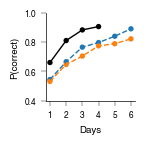

In [13]:
fig,ax = plt.subplots()
fig.set(figheight=100/75,figwidth=100/75)

# categorical
ax.plot(range(1,5),lr1,linewidth=1,color="black")
ax.scatter(range(1,5),lr1,s=15,edgecolors="None",color="black")
# randomization L2
ax.plot(range(1,7),lr2,linewidth=1,linestyle='--',color="tab:blue")
ax.scatter(range(1,7),lr2,s=15,edgecolors="None",linestyle='--',color="tab:blue")    
# randomization L3
ax.plot(range(1,7),lr3,linewidth=1,linestyle='--',color="tab:orange")
ax.scatter(range(1,7),lr3,s=15,edgecolors="None",linestyle='--',color="tab:orange")  

ax.set_ylim([0.4,1]) 
ax.set_xticks([1,2,3,4,5,6])
ax.set_ylabel("P(correct)")
ax.set_xlabel("Days")

plt.savefig(FIGURE_OUTPUT_DIR / f"randomization_learning_curve.pdf")
plt.show()


## Panel H — Category-level generalization

### Generalization stats

In [14]:

cr_L2,se_L2 = [],[]
res_gen_L2 = []
for monkey in ["Elsa","Judy","Olaf"]:
    trials,_ = loadTrialsM("randomization_test_L2_gen",monkey,islearn=False,extend=True)
    trials_gen = [trial for trial in trials if trial["trial_type"]=="gen"]
    first_trials,_ = first_trials_by_image(trials_gen)
    cr_image = [tr["result"]=="CORRECT" for tr in first_trials]
    cr_monkey = np.mean(cr_image)
    se_monkey = np.sqrt(np.mean(cr_image)*(1-np.mean(cr_image))/len(cr_image))
    cr_L2.append(cr_monkey)
    se_L2.append(se_monkey)
    res_gen_L2.append(cr_image)


In [15]:

print("Randomization L2 Generalization; Binomial Test")
for i,monkey in enumerate(["Elsa","Judy","Olaf"]):
    result1 = binomtest(int(np.sum(res_gen_L2[i])), n=len(res_gen_L2[i]), p=cr_categorical[i], alternative='less')
    result2 = binomtest(int(np.sum(res_gen_L2[i])), n=len(res_gen_L2[i]), p=0.5, alternative='greater')
    print(f"{monkey}: Lower than Categorical Generalization: P_value:{result1.pvalue:.4}; \
            \n      Higher than 0.5: P_value:{result2.pvalue:.4}")


Randomization L2 Generalization; Binomial Test
Elsa: Lower than Categorical Generalization: P_value:0.01182;             
      Higher than 0.5: P_value:0.002786
Judy: Lower than Categorical Generalization: P_value:4.41e-05;             
      Higher than 0.5: P_value:0.009217
Olaf: Lower than Categorical Generalization: P_value:0.002162;             
      Higher than 0.5: P_value:0.001439


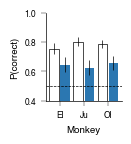

In [16]:
fig,ax = plt.subplots()
fig.set(figheight=100/75,figwidth=90/75)

colors = ["#578B6C","#59608F","#8E627B"]

barwidth = 0.4
ax.bar(np.array([1,2,3])-barwidth/2-0.03,cr_categorical,width=barwidth,edgecolor="black",linewidth=0.5,facecolor="None",yerr=se_categorical,error_kw={"linewidth":0.5})
ax.bar(np.array([1,2,3])+barwidth/2+0.03,cr_L2,width=barwidth,color="#2B77B1",yerr=se_L2,error_kw={"linewidth":0.5})

ax.axhline(0.5,color="black",linewidth=0.5,ls="--")


ax.set_xticks([1,2,3],["El","Ju","Ol"])
ax.set_yticks([0.4,0.6,0.8,1])
ax.set_ylim([0.4,1])
ax.set_xlabel("Monkey")
ax.set_ylabel("P(correct)")
plt.savefig(FIGURE_OUTPUT_DIR / f"randomization_category_generalization.pdf")
plt.show()